# Crank-Nicholson with Hines Scheme for a Passive Cable

This implements the Hines (1984) scheme for a passive cable using a Crank-Nicholson-like approach. The key idea is to write the update equation in terms of the membrane currents explicitly at the mid-time step, $t + \frac{\Delta t}{2}$.

## I. Theory

### 1. Cable Equation

The cable equation in its standard form is:

$$
C_m \frac{dV}{dt} = I_\text{inj}(t) - I_\text{ion}(V, t) + D \frac{\partial^2 V}{\partial x^2}
$$

where:  
- $V(x,t)$ is the membrane potential [mV]  
- $C_m$ is the membrane capacitance [µF/cm²]  
- $I_\text{inj}$ is the injected current density [µA/cm²]  
- $I_\text{ion}$ is the ionic current (e.g., $I_\text{HH}$ for Hodgkin-Huxley or passive leak)  
- $D$ is the diffusion coefficient representing axial conductance

### 2. Time Discretization (Hines 1984)

The Hines scheme uses a **midpoint evaluation** of the ionic current:

$$
V^{n+1/2} = V^n + \frac{\Delta t}{2 C_m} \left[ I_\text{inj}\left(t + \frac{\Delta t}{2}\right) - I_\text{ion}\left(V^{n+1/2}, t + \frac{\Delta t}{2}\right) \right]
$$

where:  
- $V^n$ is the voltage at time step $n$  
- $V^{n+1/2}$ is the intermediate voltage at mid-step  
- $\Delta t$ is the time step

This is an **implicit midpoint evaluation**, with the ionic current evaluated at the midpoint voltage $V^{n+1/2}$.

### 3. Spatial Discretization

Using finite differences for the axial diffusion term:

$$
\frac{\partial^2 V}{\partial x^2} \approx \frac{V_{i-1} - 2 V_i + V_{i+1}}{\Delta x^2}
$$

The discretized update for the intermediate voltage is:

$$
\underbrace{
\left(1 + 2 \alpha \right) V_i^{n+1/2} - \alpha V_{i-1}^{n+1/2} - \alpha V_{i+1}^{n+1/2}
}_{\text{Matrix } A \cdot V^{n+1/2}}
=
V_i^n + \frac{\Delta t}{2 C_m} \left[ I_\text{inj}\left(t + \frac{\Delta t}{2}\right) - I_\text{ion}\left(V_i^n, t + \frac{\Delta t}{2}\right) \right]
$$

with:

$$
\alpha = \frac{D \Delta t}{2 \Delta x^2}
$$

and $A$ is a tri-diagonal matrix. We solve:

$$
A \cdot V^{n+1/2} = \text{RHS}
$$

Boundary conditions are:

$$
V_0 = V_\text{init}, \quad V_{N_x-1} = V_\text{init}
$$

### 4. Full Update (Extrapolation)

After solving for $V^{n+1/2}$, the next time step voltage is extrapolated as:

$$
V^{n+1} = 2 V^{n+1/2} - V^n
$$

## II. Implementation for the Passive Cable

First let's implement it for the passive cable. The passive membrane current is time invariant hence the equation simplifies to:

$$

\left(1 + 2 \alpha \right) V_i^{n+1/2} - \alpha V_{i-1}^{n+1/2} - \alpha V_{i+1}^{n+1/2}
=
V_i^n + \frac{\Delta t}{2 C_m} \left[ I_\text{inj}\left(t + \frac{\Delta t}{2}\right) - I_\text{ion}\left(V_i^n\right) \right]
$$

In [56]:
import numpy as np
import matplotlib.pyplot as plt

from axonscope.axons import Passive, Axon
from axonscope.solvers import Solver, Euler
from axonscope.simresult import SimResult
from axonscope.benchmark import Benchmark
from axonscope.math_functions import vtrap

bench = Benchmark()

In [57]:
class CrankNicholson_Passive():
    """
    Unoptimiserd implementation of the Hines (1984) scheme for a passive cable.
    """

    def __init__(self):
        pass

    @bench.benchmark(level=1)
    def solve(self, axon, tsim, dt) -> SimResult:
        Nx = axon.Nx
        Nt = int(np.ceil(tsim / dt))

        V = np.ones(Nx) * axon.Vinit
        V_all = np.zeros((Nt, Nx))
        t_vec = np.zeros(Nt)

        dx2 = axon.dx_cm ** 2
        alpha = axon.D * (dt / 2.0) / dx2  # diffusion coefficient

        # Construct the tridiagonal matrix A (time-independent)
        A = np.zeros((Nx, Nx))
        for i in range(1, Nx-1):
            A[i, i-1] = -alpha
            A[i, i]   = 1.0 + 2.0*alpha
            A[i, i+1] = -alpha
        A[0, 0]   = 1.0
        A[-1, -1] = 1.0

        for n in range(Nt):
            t_mid = n*dt + dt/2.0
            t_vec[n] = n*dt

            # -----------------------------
            # Hines equation:
            # (A) V^{1/2} = V^n + (dt/2Cm)[ I_inj(t+dt/2) - I_HH(V^{1/2}, t+dt/2) ]
            # -----------------------------

            # Right-hand side: V^n + (dt/2Cm) * (I_inj - Iion)
            rhs = np.array(V, copy=True)
            Iinj = axon.Iinj_uAcm2(t_mid)  # [µA/cm²]
            Iion = axon.Iion(V)
            rhs += (dt / (2.0 * axon.Cm)) * (Iinj - Iion)

            # Boundary conditions
            rhs[0]  = axon.Vinit
            rhs[-1] = axon.Vinit

            
            V_half = np.linalg.solve(A, rhs)

            # Explicit update (Hines: extrapolation)
            V_new = 2.0 * V_half - V
            V_new[0]  = axon.Vinit
            V_new[-1] = axon.Vinit

            V_all[n, :] = V_new
            V = V_new

        return SimResult(axon, V_all, t_vec)

Let's test this implementation on a 1µm and compare results with the Euler Solver

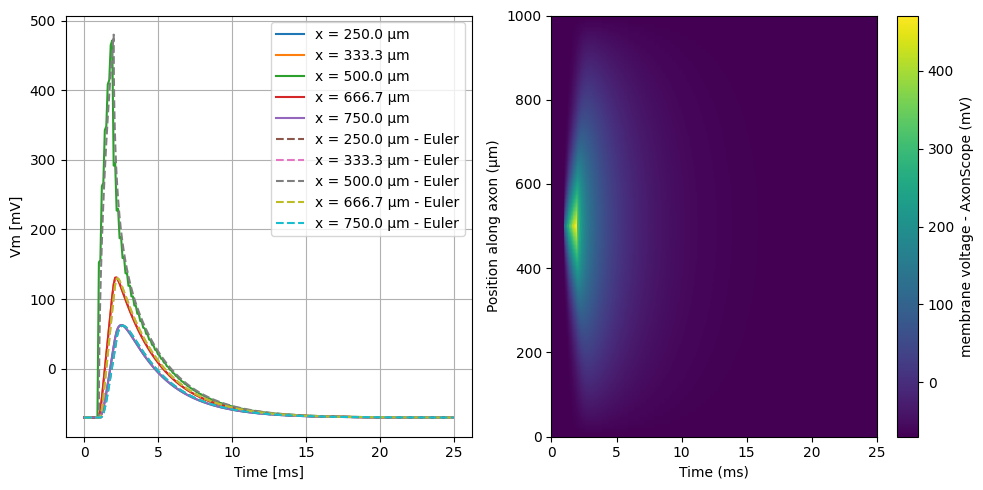

In [58]:
# --- axon parameters
L = 1000    #in µm
d = 1       # diameter in µm
Nx = 101
axon = Passive(L=L, d=d, Nx=Nx)

#Inject current 1ms pulse 
t_start = 1.0
duration = 1.0
amplitude = 5
axon.insert_I_Clamp(position=L / 2, t_start=t_start, duration=duration, amplitude=amplitude)

# --- solver setup
solver = CrankNicholson_Passive()
tsim = 25.0         # total simulation time [ms]
dt = 0.1          # time step [ms]

res_CN = solver.solve(axon, tsim=tsim, dt=dt)

# ---- Choose positions along the axon ----
x_positions = [L/4, L/3, L/2, 2*L/3, 3*L/4]
indices = [np.argmin(np.abs(axon.x - xp)) for xp in x_positions]

fig, axs = plt.subplots(1,2, figsize=(10,5))
for idx, xp in zip(indices, x_positions):
    axs[0].plot(res_CN.t, res_CN.Vm[:, idx], label=f'x = {xp:.1f} µm')


solver = Euler()
res_EULER = solver.solve(axon, tsim=tsim, dt=0.001)

x_positions = [L/4, L/3, L/2, 2*L/3, 3*L/4]
indices = [np.argmin(np.abs(axon.x - xp)) for xp in x_positions]

for idx, xp in zip(indices, x_positions):
    axs[0].plot(res_EULER.t, res_EULER.Vm[:, idx],'--', label=f'x = {xp:.1f} µm - Euler')

axs[0].set_xlabel('Time [ms]')
axs[0].set_ylabel('Vm [mV]')
axs[0].legend()
axs[0].grid(True)

# --- Plot 2: 2D space–time voltage map
extent = [0, tsim, 0, L]  # [time(ms), position(cm)]
map = axs[1].imshow(
    res_CN.Vm.T,
    aspect="auto",
    extent=extent,
    origin="lower",
    cmap="viridis"
)

axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("Position along axon (µm)")
cbar = fig.colorbar(map)
cbar.set_label('membrane voltage - AxonScope (mV)')
fig.tight_layout()

Note how the Crank-Nicholson solution remains stable even though the time discretization is large!

## III. Implementation for an HH-based cable

The gating variables \(m\), \(h\), and \(n\) are updated at the mid-step as follows (Hines 1984):

$$
m\Big(V, t + \frac{\Delta t}{2}\Big) =
\frac{\alpha_m(V)}{\frac{1}{\Delta t} + \frac{\alpha_m(V) + \beta_m(V)}{2}}
+ \frac{\frac{1}{\Delta t} - \frac{\alpha_m(V) + \beta_m(V)}{2}}{\frac{1}{\Delta t} + \frac{\alpha_m(V) + \beta_m(V)}{2}}
\, m\Big(t - \frac{\Delta t}{2}\Big)
$$

$$
h\Big(V, t + \frac{\Delta t}{2}\Big) =
\frac{\alpha_h(V)}{\frac{1}{\Delta t} + \frac{\alpha_h(V) + \beta_h(V)}{2}}
+ \frac{\frac{1}{\Delta t} - \frac{\alpha_h(V) + \beta_h(V)}{2}}{\frac{1}{\Delta t} + \frac{\alpha_h(V) + \beta_h(V)}{2}}
\, h\Big(t - \frac{\Delta t}{2}\Big)
$$

$$
n\Big(V, t + \frac{\Delta t}{2}\Big) =
\frac{\alpha_n(V)}{\frac{1}{\Delta t} + \frac{\alpha_n(V) + \beta_n(V)}{2}}
+ \frac{\frac{1}{\Delta t} - \frac{\alpha_n(V) + \beta_n(V)}{2}}{\frac{1}{\Delta t} + \frac{\alpha_n(V) + \beta_n(V)}{2}}
\, n\Big(t - \frac{\Delta t}{2}\Big)
$$

In [ ]:
def update_gate_halfstep(g_prev, alpha_fun, beta_fun, V, dt, q10):
    """
    Update a gating variable (m, h, n) at half step using the Hines CN scheme.

    g_prev : value of g(t - dt/2)
    alpha_fun, beta_fun : functions alpha(V), beta(V)
    V : membrane potential [mV]
    dt : time step [ms]
    q10 : temperature factor
    """
    alpha = q10 * alpha_fun(V)
    beta  = q10 * beta_fun(V)
    denom = (1.0/dt) + 0.5*(alpha + beta)
    term1 = alpha / denom
    term2 = ((1.0/dt) - 0.5*(alpha + beta)) / denom * g_prev
    return term1 + term2


#Cable implementation compatible with the Crank-Nicholson scheme 
class RattayAberham_CN(Axon):

    def __init__(
        self,
        L,
        d,
        Nx=101,
        Cm=1.0,
        Ra=100.0,
        Vinit=-70.0,
        gnabar=0.12,   # S/cm^2
        gkbar=0.036,   # S/cm^2
        gl=0.0003,     # S/cm^2
        el=-59.4,      # mV
        ena=45.0,      # mV
        ek=-82.0,      # mV
        celsius=37.0,  # degC
    ):
        super().__init__(L=L, d=d, Nx=Nx, Cm=Cm, Ra=Ra, Vinit=Vinit)

        # channel parameters
        self.gnabar = float(gnabar)
        self.gkbar = float(gkbar)
        self.gl = float(gl)
        self.el = float(el)
        self.ena = float(ena)
        self.ek = float(ek)
        self.celsius = float(celsius)
        self.q10 = np.power(2.24659524757, (self.celsius - 6.3) / 10.0)

        # gating variables (per compartment)
        self.m = np.zeros(self.Nx, dtype=float)
        self.h = np.zeros(self.Nx, dtype=float)
        self.n = np.zeros(self.Nx, dtype=float)

        # initialize gating variables at Vinit equilibrium
        V0 = np.ones(self.Nx) * float(self.Vinit)
        minf, mtau, hinf, htau, ninf, ntau = self._rates(V0)
        self.m[:] = minf
        self.h[:] = hinf
        self.n[:] = ninf

        


    def alpha_m(self, V_m):
        return(vtrap(2.5 - 0.1 * (V_m + 70.0), 1.0))

    def beta_m(self, V_m):
        return(4.0 * np.exp(-(V_m + 70.0) / 18.0))

    def alpha_h(self, V_m):
        return(0.07 * np.exp(-(V_m + 70.0) / 20.0))
    
    def beta_h(self, V_m):
        return(1.0 / (np.exp(3.0 - 0.1 * (V_m + 70.0)) + 1.0))    

    def alpha_n(self, V_m):
        return(0.1 * vtrap(1.0 - 0.1 * (V_m + 70.0), 1.0))
    
    def beta_n(self, V_m):
        return(0.1 * vtrap(1.0 - 0.1 * (V_m + 70.0), 1.0))   
    

    @bench.benchmark(level=2)  
    def _rates(self, V_mV):
        v = np.asarray(V_mV, dtype=float)
        
        
        # m
        sum_m = np.maximum(self.alpha_m(v) + self.beta_m(v), 1e-12)
        mtau = 1.0 / (self.q10 * sum_m)
        minf = self.alpha_m(v) / sum_m

        # h
        sum_h = np.maximum(self.alpha_h(v) + self.beta_h(v), 1e-12)
        htau = 1.0 / (self.q10 * sum_h)
        hinf = self.alpha_h(v) / sum_h

        # n
        sum_n = np.maximum(self.alpha_n(v) + self.beta_n(v), 1e-12)
        ntau = 1.0 / (self.q10 * sum_n)
        ninf = self.alpha_n(v) / sum_n

        return minf, mtau, hinf, htau, ninf, ntau

    # ---- gating integration (cnexp style) ----
    @bench.benchmark(level=2)  
    def step_gates(self, dt_ms, V_mV):
        """Advance gating variables with time step dt_ms (ms) and voltages V_mV (mV)."""
        if dt_ms <= 0.0:
            return

        V = np.asarray(V_mV, dtype=float)
        if V.shape != (self.Nx,):
            V = np.full(self.Nx, float(V.item()))

        minf, mtau, hinf, htau, ninf, ntau = self._rates(V)

        mtau = np.maximum(mtau, 1e-12)
        htau = np.maximum(htau, 1e-12)
        ntau = np.maximum(ntau, 1e-12)

        self.m = minf - (minf - self.m) * np.exp(-dt_ms / mtau)
        self.h = hinf - (hinf - self.h) * np.exp(-dt_ms / htau)
        self.n = ninf - (ninf - self.n) * np.exp(-dt_ms / ntau)

    # -- gating half step -- for Crank Nicholson solver
    def half_step_gates(self, dt_ms, V_mV):
        """Advance gating variables in half time step dt_ms (ms) and voltages V_mV (mV).
        """

        if dt_ms <= 0.0:
            return
        
        V = np.asarray(V_mV, dtype=float)
        if V.shape != (self.Nx,):
            V = np.full(self.Nx, float(V.item()))

        self.m = update_gate_halfstep(self.m, self.alpha_m, self.beta_m, V, dt_ms, self.q10)
        self.h = update_gate_halfstep(self.h, self.alpha_h, self.beta_h, V, dt_ms, self.q10)
        self.n = update_gate_halfstep(self.n, self.alpha_n, self.beta_n, V, dt_ms, self.q10)


    # ---- ionic currents ----
    @bench.benchmark(level=2)  
    def Iion(self, V):
        """Return ionic current density [µA/cm²] at time t (ms) for V (mV)."""
        V_arr = np.asarray(V, dtype=float)
        if V_arr.shape != (self.Nx,):
            V_arr = np.full(self.Nx, float(V_arr.item()))

        gna = self.gnabar * (self.m ** 3) * self.h   # S/cm^2
        gk = self.gkbar * (self.n ** 4)              # S/cm^2
        gl = self.gl                                 # S/cm^2

        ina = gna * (V_arr - self.ena) * 1e3  # µA/cm^2
        ik = gk * (V_arr - self.ek) * 1e3
        il = gl * (V_arr - self.el) * 1e3

        return ina + ik + il
    

class CrankNicholson_HH():
    """
    Unoptimised implementation of the Hines (1984) scheme for a HH-based cable.
    """

    def __init__(self):
        pass

    @bench.benchmark(level=1)
    def solve(self, axon:RattayAberham_CN, tsim, dt) -> SimResult:
        Nx = axon.Nx
        Nt = int(np.ceil(tsim / dt))

        V = np.ones(Nx) * axon.Vinit
        V_all = np.zeros((Nt, Nx))
        t_vec = np.zeros(Nt)

        dx2 = axon.dx_cm ** 2
        alpha = axon.D * (dt / 2.0) / dx2  # diffusion coefficient

        # Construct the tridiagonal matrix A (time-independent)
        A = np.zeros((Nx, Nx))
        for i in range(1, Nx-1):
            A[i, i-1] = -alpha
            A[i, i]   = 1.0 + 2.0*alpha
            A[i, i+1] = -alpha
        A[0, 0]   = 1.0
        A[-1, -1] = 1.0

        for n in range(Nt):
            t_mid = n*dt + dt/2.0
            t_vec[n] = n*dt

            # -----------------------------
            # Hines equation:
            # (A) V^{1/2} = V^n + (dt/2Cm)[ I_inj(t+dt/2) - I_HH(V^{1/2}, t+dt/2) ]
            # -----------------------------

            # Right-hand side: V^n + (dt/2Cm) * (I_inj - I_HH)
            rhs = np.array(V, copy=True)
            Iinj = axon.Iinj_uAcm2(t_mid)  # [µA/cm²]
            
            Iion = axon.Iion(V)
            rhs += (dt / (2.0 * axon.Cm)) * (Iinj - Iion)

            axon.half_step_gates(dt, V)

            # Boundary conditions
            rhs[0]  = axon.Vinit
            rhs[-1] = axon.Vinit


            V_half = np.linalg.solve(A, rhs)

            # Explicit update (Hines: extrapolation)
            V_new = 2.0 * V_half - V
            V_new[0]  = axon.Vinit
            V_new[-1] = axon.Vinit

            V_all[n, :] = V_new
            V = V_new

        return SimResult(axon, V_all, t_vec)

Let's test this implementation on a 1µm and compare results with the Euler Solver

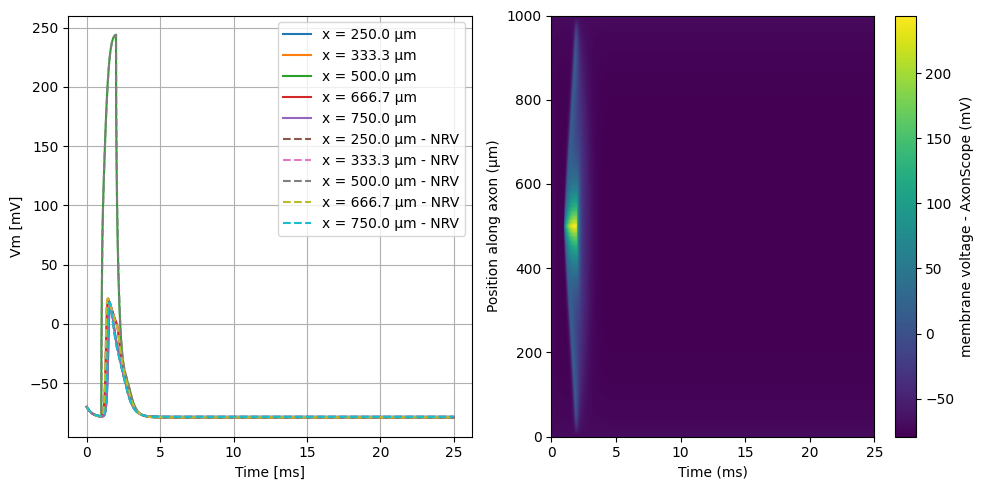

In [60]:
axon = RattayAberham_CN(L=L, d=d, Nx=Nx)
axon.insert_I_Clamp(position=L / 2, t_start=t_start, duration=duration, amplitude=amplitude)

# --- solver setup
solver = CrankNicholson_HH()
tsim = 25.0         # total simulation time [ms]
dt = 0.01          # time step [ms]

res_CN = solver.solve(axon, tsim=tsim, dt=dt)

fig, axs = plt.subplots(1,2, figsize=(10,5))
for idx, xp in zip(indices, x_positions):
    axs[0].plot(res_CN.t, res_CN.Vm[:, idx], label=f'x = {xp:.1f} µm')

solver = Euler()
res_EULER = solver.solve(axon, tsim=tsim, dt=0.001)

x_positions = [L/4, L/3, L/2, 2*L/3, 3*L/4]
indices = [np.argmin(np.abs(axon.x - xp)) for xp in x_positions]

for idx, xp in zip(indices, x_positions):
    axs[0].plot(res_EULER.t, res_EULER.Vm[:, idx],"--", label=f'x = {xp:.1f} µm - NRV')

axs[0].set_xlabel('Time [ms]')
axs[0].set_ylabel('Vm [mV]')
axs[0].legend()
axs[0].grid(True)

# --- Plot 2: 2D space–time voltage map
extent = [0, tsim, 0, L]  # [time(ms), position(cm)]
map = axs[1].imshow(
    res_CN.Vm.T,
    aspect="auto",
    extent=extent,
    origin="lower",
    cmap="viridis"
)

axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("Position along axon (µm)")
cbar = fig.colorbar(map)
cbar.set_label('membrane voltage - AxonScope (mV)')
fig.tight_layout()